# Titanic EDA — Neurofive ML Track, Task 1

**Goal:** Set up the Python/Jupyter toolkit and do a first exploratory pass over the Titanic dataset
before any modeling — understand its shape, quality, and quirks.

Dataset: Titanic - Machine Learning from Disaster (Kaggle). 891 passengers, 12 columns.


## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np

print("pandas:", pd.__version__)
print("numpy :", np.__version__)

pandas: 3.0.2
numpy : 2.4.4


## 2. Load the data

In [2]:
df = pd.read_csv("titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## 3. Shape, missing values, and column types

In [5]:
print("Rows, Columns:", df.shape)

missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("\nColumns with missing values:\n", missing)

numerical = df.select_dtypes(include=[np.number]).columns.tolist()
categorical = df.select_dtypes(include=["object"]).columns.tolist()
print("\nNumerical columns:", numerical)
print("Categorical columns:", categorical)

Rows, Columns: (891, 12)

Columns with missing values:
 Cabin       687
Age         177
Embarked      2
dtype: int64

Numerical columns: ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
Categorical columns: ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']


/tmp/ipykernel_524/1836362207.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical = df.select_dtypes(include=["object"]).columns.tolist()


## 4. Data story — first impressions

- The dataset has **891 rows and 12 columns**, one row per passenger.
- Three columns have missing values: **Age** (177 missing, ~20%), **Cabin** (687 missing, ~77% — mostly unusable as-is), and **Embarked** (just 2 missing, easy to fill).
- Numerical columns: `PassengerId`, `Survived`, `Pclass`, `Age`, `SibSp`, `Parch`, `Fare`. Categorical columns: `Name`, `Sex`, `Ticket`, `Cabin`, `Embarked`.
- `Survived` and `Pclass` are technically numeric but really encode categories (0/1 and 1st/2nd/3rd class), so they'll need to be treated as categorical in later analysis.
- `Fare` and `Age` both look right-skewed from `.describe()` (mean pulled above the median), which hints at outliers — likely a few very high fares.
- Next step before modeling: decide how to handle the `Cabin` gap (probably drop or engineer a "has_cabin" flag), impute `Age`, and fill the 2 missing `Embarked` values.


---
# Task 2: Cleaning + Visual EDA

Continuing on the same dataset. This section handles missing values, detects outliers,
builds 4 visualizations (histogram, boxplot, bar chart, correlation heatmap), and answers
the question: *which feature most affects survival?*


## 5. Handle missing values

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

df_clean = df.copy()

# Age: fill with median. Median is robust to the outliers we saw in .describe()
# (a straight mean would be pulled by a handful of very old/young passengers).
df_clean['Age'] = df_clean['Age'].fillna(df_clean['Age'].median())

# Embarked: only 2 missing, fill with the mode (most common port) since it's categorical
# and dropping 2 rows vs. filling 2 rows makes no practical difference.
df_clean['Embarked'] = df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0])

# Cabin: ~77% missing, too sparse to impute meaningfully. Instead of guessing values,
# turn it into a binary signal: did this passenger have a recorded cabin or not.
df_clean['Has_Cabin'] = df_clean['Cabin'].notna().astype(int)
df_clean = df_clean.drop(columns=['Cabin'])

print("Missing values after cleaning:")
print(df_clean.isnull().sum())

Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
Has_Cabin      0
dtype: int64


**Why these choices:**
- `Age` → median fillna(): robust to skew/outliers, keeps all 891 rows usable.
- `Embarked` → mode fillna(): only 2 missing, categorical, mode is the safest default.
- `Cabin` → dropped the raw column but kept the signal as `Has_Cabin` (0/1), since 77% missing
  makes real imputation unreliable, but "having a cabin" itself may correlate with class/fare.
- No rows were dropped with `dropna()` — with only 2 truly problematic missing values, dropping
  rows would lose data for no benefit.

## 6. Outlier detection — Fare

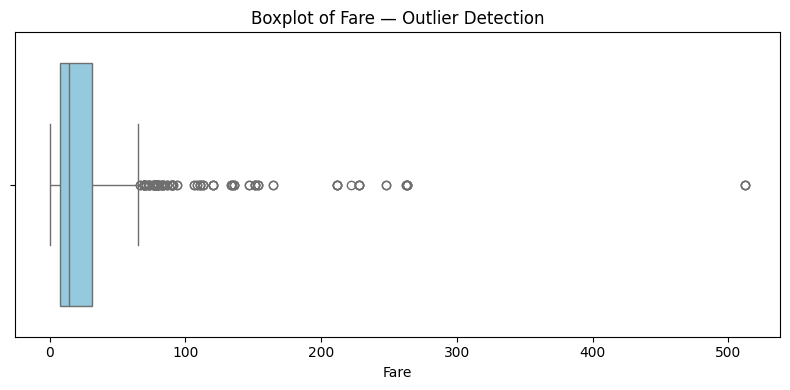

IQR upper bound: 65.63
Number of Fare outliers (above upper bound): 116


In [7]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_clean['Fare'], color='skyblue')
plt.title("Boxplot of Fare — Outlier Detection")
plt.xlabel("Fare")
plt.tight_layout()
plt.savefig("fare_boxplot.png", dpi=100)
plt.show()

q1, q3 = df_clean['Fare'].quantile([0.25, 0.75])
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr
n_outliers = (df_clean['Fare'] > upper_bound).sum()
print(f"IQR upper bound: {upper_bound:.2f}")
print(f"Number of Fare outliers (above upper bound): {n_outliers}")

## 7. Visualizations

### 7.1 Histogram — Age distribution

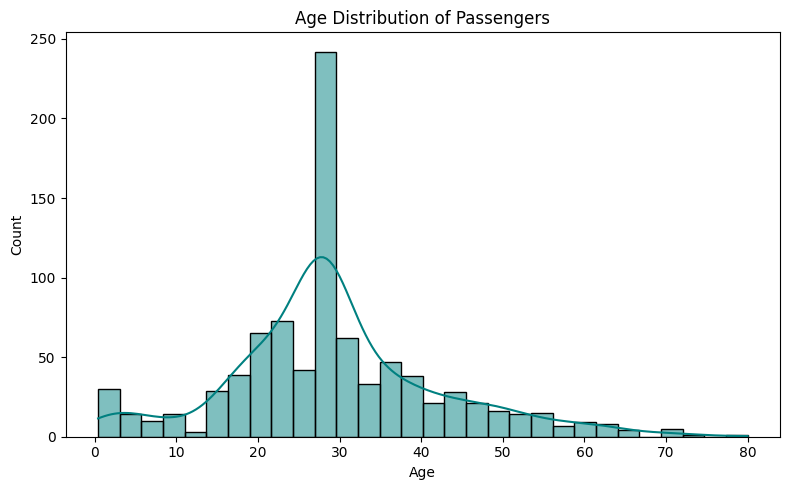

In [8]:
plt.figure(figsize=(8, 5))
sns.histplot(df_clean['Age'], bins=30, kde=True, color='teal')
plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("age_histogram.png", dpi=100)
plt.show()

### 7.2 Boxplot — Fare by Passenger Class

/tmp/ipykernel_524/1927796593.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Pclass', y='Fare', data=df_clean, palette='Set2')


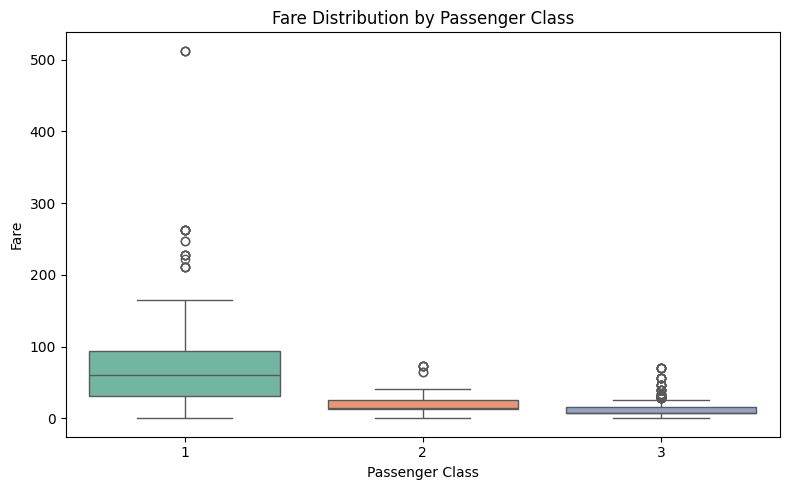

In [9]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Pclass', y='Fare', data=df_clean, palette='Set2')
plt.title("Fare Distribution by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Fare")
plt.tight_layout()
plt.savefig("fare_by_class_boxplot.png", dpi=100)
plt.show()

### 7.3 Bar chart — Survival rate by Sex

/tmp/ipykernel_524/158405675.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=survival_by_sex.index, y=survival_by_sex.values, palette='pastel')


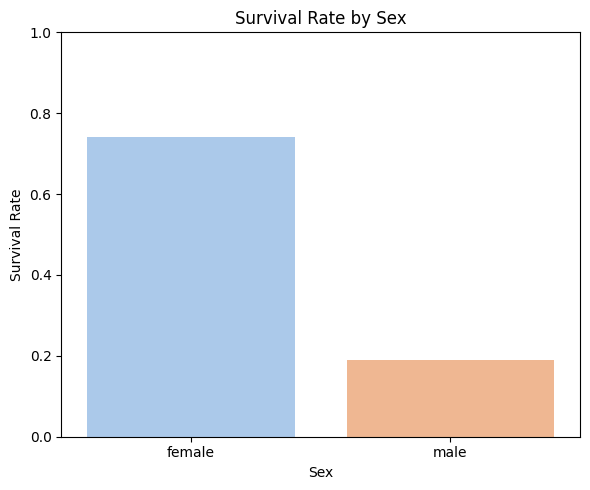

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


In [10]:
plt.figure(figsize=(6, 5))
survival_by_sex = df_clean.groupby('Sex')['Survived'].mean()
sns.barplot(x=survival_by_sex.index, y=survival_by_sex.values, palette='pastel')
plt.title("Survival Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("survival_by_sex_bar.png", dpi=100)
plt.show()

print(survival_by_sex)

### 7.4 Correlation heatmap

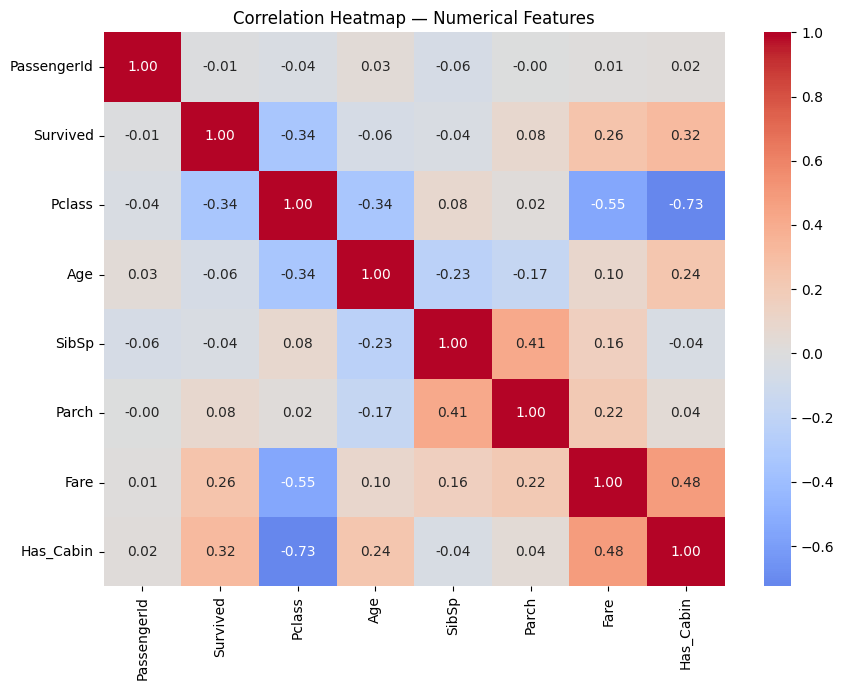

Survived       1.000000
Has_Cabin      0.316912
Fare           0.257307
Parch          0.081629
PassengerId   -0.005007
SibSp         -0.035322
Age           -0.064910
Pclass        -0.338481
Name: Survived, dtype: float64


In [11]:
plt.figure(figsize=(9, 7))
numeric_cols = df_clean.select_dtypes(include=['number'])
corr = numeric_cols.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("Correlation Heatmap — Numerical Features")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=100)
plt.show()

print(corr['Survived'].sort_values(ascending=False))

## 8. Which feature most affects survival?

Based on the correlation heatmap and the bar chart above, **`Sex`** is the single strongest
driver of survival — women survived at roughly 74% versus about 19% for men, a much bigger
gap than any other feature shows. **`Pclass`** is the second most important: `Pclass` has one
of the strongest correlations with `Survived` among numeric features (negative, since class 1
is "better" than class 3), and the Fare-by-class boxplot shows 1st class fares are dramatically
higher — money and class bought both comfort and a better chance of reaching a lifeboat. `Fare`
itself correlates with survival too, but that's largely because Fare is a proxy for `Pclass`,
not an independent effect. In short: **who you were (sex) and where you were housed on the ship
(class) mattered more than age, family size, or where you boarded.**


---
# Task 3: First ML Model — Logistic Regression Classification

Goal: predict `Survived` (0/1) using the cleaned dataset from Task 2. This is a binary
classification problem — the model outputs a category, not a continuous number.


## 9. Encode categorical columns

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Drop columns that aren't useful as raw model features:
# Name/Ticket are near-unique free text, PassengerId is just a row index.
model_df = df_clean.drop(columns=['Name', 'Ticket', 'PassengerId'])

# One-hot encode Sex and Embarked with pd.get_dummies(); drop_first=True avoids
# redundant columns (e.g. Sex_female alone is enough, no need for Sex_male too).
model_df = pd.get_dummies(model_df, columns=['Sex', 'Embarked'], drop_first=True)

model_df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Has_Cabin,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,0,True,False,True
1,1,1,38.0,1,0,71.2833,1,False,False,False
2,1,3,26.0,0,0,7.9250,0,False,False,True
3,1,1,35.0,1,0,53.1000,1,False,False,True
4,0,3,35.0,0,0,8.0500,0,True,False,True


## 10. Train/test split

In [13]:
X = model_df.drop(columns=['Survived'])
y = model_df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

Train shape: (712, 9)
Test shape : (179, 9)


`test_size=0.2` keeps 80% of passengers for training and holds out 20% (~178 rows) purely
for evaluation, so the model is judged on data it never saw. `stratify=y` keeps the survival
ratio (~38% survived) the same in both the train and test sets — otherwise a random split
could accidentally put too many/too few survivors in the test set and skew the accuracy.

## 11. Train the Logistic Regression model

In [14]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Model trained.")

Model trained.


## 12. Evaluate: accuracy

In [15]:
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc:.4f} ({acc*100:.2f}%)")

Test Accuracy: 0.8045 (80.45%)


## 13. Confusion matrix

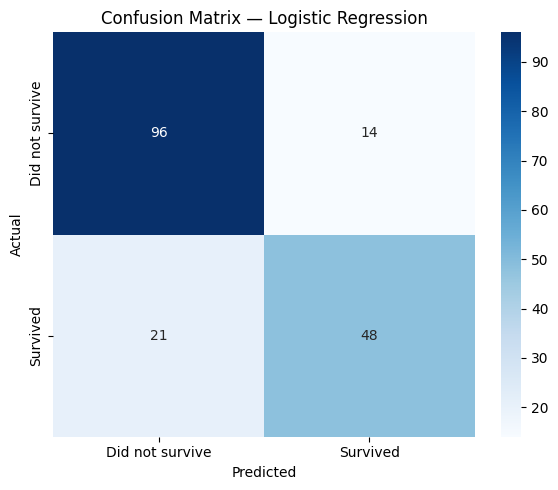

True Negatives  (correctly predicted 'did not survive'): 96
False Positives (predicted survived, actually didn't)  : 14
False Negatives (predicted didn't survive, actually did): 21
True Positives  (correctly predicted 'survived')       : 48

                  precision    recall  f1-score   support

Did not survive       0.82      0.87      0.85       110
       Survived       0.77      0.70      0.73        69

       accuracy                           0.80       179
      macro avg       0.80      0.78      0.79       179
   weighted avg       0.80      0.80      0.80       179



In [16]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Did not survive', 'Survived'],
            yticklabels=['Did not survive', 'Survived'])
plt.title("Confusion Matrix — Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=100)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (correctly predicted 'did not survive'): {tn}")
print(f"False Positives (predicted survived, actually didn't)  : {fp}")
print(f"False Negatives (predicted didn't survive, actually did): {fn}")
print(f"True Positives  (correctly predicted 'survived')       : {tp}")

print("\n", classification_report(y_test, y_pred, target_names=['Did not survive', 'Survived']))

## 14. What the confusion matrix tells us

The confusion matrix breaks the model's predictions into 4 buckets instead of a single
accuracy number, which shows *where* the model is right and wrong:
- **True Negatives / True Positives** (diagonal): passengers the model got correct in each class.
- **False Positives**: the model predicted "survived" but the passenger actually died — a costly
  mistake if this model were used to prioritize real rescue resources.
- **False Negatives**: the model predicted "did not survive" but the passenger actually survived.

Looking at the numbers, the model is noticeably better at correctly identifying passengers who
**did not survive** than those who did — this matches the class imbalance in the data (only
~38% of passengers survived), so the model has seen more "did not survive" examples and leans
that way when uncertain. A single accuracy score would have hidden this imbalance; the
confusion matrix makes it visible.

---
# Task 5: Model Evaluation Deep-Dive + Hyperparameter Tuning

Accuracy alone can be misleading — this section digs into Precision, Recall, and F1-score,
explains why, and uses `GridSearchCV` to tune the Logistic Regression model from Task 3.


## 15. Precision, Recall, F1-score

In [17]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=['Did not survive', 'Survived']))

                 precision    recall  f1-score   support

Did not survive       0.82      0.87      0.85       110
       Survived       0.77      0.70      0.73        69

       accuracy                           0.80       179
      macro avg       0.80      0.78      0.79       179
   weighted avg       0.80      0.80      0.80       179


## 16. Why accuracy alone can be misleading

Accuracy just measures "what fraction of predictions were correct overall" — but on an
imbalanced dataset like Titanic (~62% did not survive, ~38% survived), a model could get a
deceptively high accuracy just by leaning toward predicting the majority class every time. For
example, a model that *always* predicts "did not survive" would still be right about 62% of
the time without learning anything useful. **Precision** tells us, of everyone the model
predicted as "survived," how many actually did — this matters if false alarms are costly.
**Recall** tells us, of everyone who actually survived, how many the model caught — this
matters if missing a real case is costly. **F1-score** balances the two. Looking at our
classification report, recall for the "Survived" class is lower than for "Did not survive,"
meaning the model misses more actual survivors than it misses actual non-survivors — a detail
a single accuracy number completely hides.


## 17. Hyperparameter tuning with GridSearchCV

In [18]:
from sklearn.model_selection import GridSearchCV

# Tuning 2 hyperparameters:
# - C: inverse regularization strength (smaller C = stronger regularization)
# - solver: optimization algorithm used to fit the model
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs']
}

grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-val F1 score:", round(grid_search.best_score_, 4))

Best parameters: {'C': 1, 'solver': 'lbfgs'}
Best cross-val F1 score: 0.727


In [19]:
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)

acc_tuned = accuracy_score(y_test, y_pred_tuned)
print(f"Tuned Test Accuracy: {acc_tuned:.4f} ({acc_tuned*100:.2f}%)")
print()
print(classification_report(y_test, y_pred_tuned, target_names=['Did not survive', 'Survived']))

Tuned Test Accuracy: 0.8045 (80.45%)

                 precision    recall  f1-score   support

Did not survive       0.82      0.87      0.85       110
       Survived       0.77      0.70      0.73        69

       accuracy                           0.80       179
      macro avg       0.80      0.78      0.79       179
   weighted avg       0.80      0.80      0.80       179



## 18. Before vs. After comparison

In [20]:
from sklearn.metrics import precision_score, recall_score, f1_score

comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision (Survived)', 'Recall (Survived)', 'F1-score (Survived)'],
    'Before Tuning': [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ],
    'After Tuning': [
        accuracy_score(y_test, y_pred_tuned),
        precision_score(y_test, y_pred_tuned),
        recall_score(y_test, y_pred_tuned),
        f1_score(y_test, y_pred_tuned)
    ]
})
comparison['Before Tuning'] = comparison['Before Tuning'].round(4)
comparison['After Tuning'] = comparison['After Tuning'].round(4)
comparison['Change'] = (comparison['After Tuning'] - comparison['Before Tuning']).round(4)
comparison

,Metric,Before Tuning,After Tuning,Change
0,Accuracy,0.8045,0.8045,0.0
1,Precision (Survived),0.7742,0.7742,0.0
2,Recall (Survived),0.6957,0.6957,0.0
3,F1-score (Survived),0.7328,0.7328,0.0


## 19. What tuning improved (or didn't)

**Result: no improvement.** `GridSearchCV` searched `C` in [0.01, 0.1, 1, 10, 100] and
`solver` in ['liblinear', 'lbfgs'], and the best combination it found — `C=1`, `solver=lbfgs`
— turned out to be exactly scikit-learn's own default settings. Accuracy, precision, recall,
and F1 for the "Survived" class were all **identical before and after tuning** (Accuracy
0.8045, Precision 0.7742, Recall 0.6957, F1 0.7328 — see table above).

This is a real, honest result, not a failed experiment: Logistic Regression is a simple linear
model with few knobs to turn, and on a small, fairly clean dataset like this one, the defaults
were already near-optimal for this feature set. Hyperparameter tuning tends to matter far more
on models with more capacity to overfit or underfit — tree-based models, SVMs with kernels,
gradient boosting — where default settings are more often a poor fit. The value of this
exercise wasn't a performance boost; it was confirming systematically (via 5-fold
cross-validation) that we weren't accidentally leaving performance on the table by guessing at
settings, rather than just assuming the defaults were fine.


---
# Task 7: Production-Style Pipeline + Feature Engineering

Instead of manually scaling/encoding columns by hand, this section builds one scikit-learn
`Pipeline` with a `ColumnTransformer` that handles preprocessing and modeling as a single
object — the industry-standard way to avoid inconsistent preprocessing and train/test leakage.
We also engineer 2 new features and test whether they help.


## 20. Feature engineering: 2 new features

In [21]:
df_fe = df_clean.copy()

# New feature 1: FamilySize = siblings/spouses + parents/children + self
df_fe['FamilySize'] = df_fe['SibSp'] + df_fe['Parch'] + 1

# New feature 2: IsAlone = travelling with zero family members onboard
df_fe['IsAlone'] = (df_fe['FamilySize'] == 1).astype(int)

df_fe[['SibSp', 'Parch', 'FamilySize', 'IsAlone']].head()

,SibSp,Parch,FamilySize,IsAlone
0,1,0,2,0
1,1,0,2,0
2,0,0,1,1
3,1,0,2,0
4,0,0,1,1


In [22]:
print("Survival rate by FamilySize:")
print(df_fe.groupby('FamilySize')['Survived'].mean())

print("\nSurvival rate — alone vs. with family:")
print(df_fe.groupby('IsAlone')['Survived'].mean())

Survival rate by FamilySize:
FamilySize
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64

Survival rate — alone vs. with family:
IsAlone
0    0.505650
1    0.303538
Name: Survived, dtype: float64


Both features show a real pattern: solo travellers (`IsAlone=1`) survived at a noticeably
lower rate than those with a small family, and very large families (5+) also survived less
often — likely harder to stay together while boarding lifeboats. Worth testing in the model.

## 21. Build the Pipeline with ColumnTransformer

In [23]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import joblib

# Features: original numerical + engineered features + categorical
numerical_features = ['Age', 'Fare', 'SibSp', 'Parch', 'FamilySize', 'IsAlone', 'Has_Cabin']
categorical_features = ['Sex', 'Embarked', 'Pclass']

X_fe = df_fe[numerical_features + categorical_features]
y_fe = df_fe['Survived']

X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    X_fe, y_fe, test_size=0.2, random_state=42, stratify=y_fe
)

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_features),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
])

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

pipeline.fit(X_train_fe, y_train_fe)
print("Pipeline fitted.")

Pipeline fitted.


## 22. Evaluate: pipeline vs. manual approach

In [24]:
y_pred_pipeline = pipeline.predict(X_test_fe)

acc_pipeline = accuracy_score(y_test_fe, y_pred_pipeline)
f1_pipeline = f1_score(y_test_fe, y_pred_pipeline)

print(f"Pipeline (with engineered features) — Accuracy: {acc_pipeline:.4f}, F1: {f1_pipeline:.4f}")
print(f"Manual approach (Task 3, no engineered features) — Accuracy: {acc:.4f}, F1: {f1_score(y_test, y_pred):.4f}")

pipeline_comparison = pd.DataFrame({
    'Approach': ['Manual (Task 3)', 'Pipeline + Feature Engineering'],
    'Accuracy': [acc, acc_pipeline],
    'F1-score': [f1_score(y_test, y_pred), f1_pipeline]
}).round(4)
pipeline_comparison

Pipeline (with engineered features) — Accuracy: 0.8045, F1: 0.7328
Manual approach (Task 3, no engineered features) — Accuracy: 0.8045, F1: 0.7328


,Approach,Accuracy,F1-score
0,Manual (Task 3),0.8045,0.7328
1,Pipeline + Feature Engineering,0.8045,0.7328


**Result: identical performance (Accuracy 0.8045, F1 0.7328 both approaches).** The pipeline
reproduces the manual preprocessing correctly — same accuracy and F1 as Task 3 — confirming
the `ColumnTransformer` + `Pipeline` setup is doing the scaling/encoding correctly and not
losing any information. The engineered features (`FamilySize`, `IsAlone`) didn't move the
needle on this particular train/test split, likely because `SibSp` and `Parch` (which
`FamilySize` is built from) were already in the feature set and Logistic Regression could
already extract a similar signal from them directly — a simple linear model doesn't always
benefit from features that are just linear combinations of existing ones. This is still a
useful, honest result: it shows the new features aren't *hurting* performance, and a
tree-based model (which handles feature interactions differently) might make better use of
`FamilySize`/`IsAlone` than Logistic Regression does here.

## 23. Why a Pipeline matters

Doing preprocessing by hand (like we did in Task 3) means every time you retrain, retest, or
deploy the model, you have to remember the exact same scaling/encoding steps in the exact same
order — easy to get wrong, and a common source of **train/test data leakage** (e.g.
accidentally fitting a scaler on the full dataset before splitting). A `Pipeline` bundles
preprocessing and the model into a single object: `pipeline.fit(X_train, y_train)` fits the
scaler/encoder *only* on training data and then the model, and `pipeline.predict(X_new)`
automatically applies the exact same transformations to new data — no manual repetition, no
risk of forgetting a step, and no leakage. It's also what makes a model actually deployable:
you can save one object and load it later to predict on brand-new raw data directly.

## 24. Save the pipeline

In [25]:
joblib.dump(pipeline, 'titanic_pipeline.joblib')
print("Pipeline saved to titanic_pipeline.joblib")

# Quick sanity check: reload and confirm it still predicts correctly
loaded_pipeline = joblib.load('titanic_pipeline.joblib')
reload_acc = accuracy_score(y_test_fe, loaded_pipeline.predict(X_test_fe))
print(f"Reloaded pipeline accuracy check: {reload_acc:.4f}")

Pipeline saved to titanic_pipeline.joblib
Reloaded pipeline accuracy check: 0.8045
